In [5]:
!pip install psycopg2-binary pandas matplotlib

C:\Users\kmoth\AppData\Local\Temp\ipykernel_8536\1913324011.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql(query,conn)


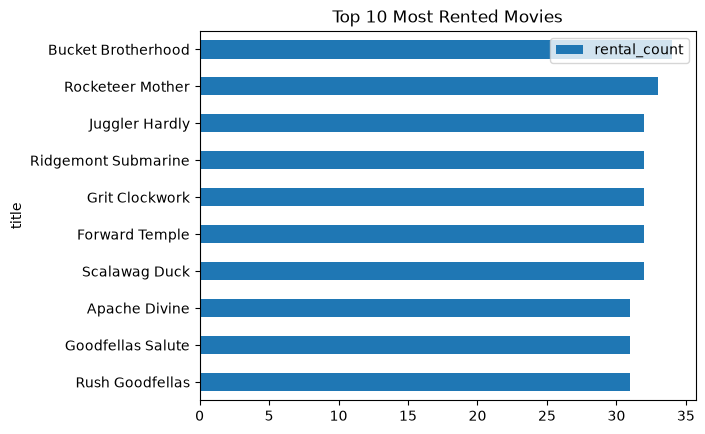

In [13]:

#Replace Your_password_Here with your local postgress password
import pandas as pd
import matplotlib.pyplot as plt
import psycopg2

conn=psycopg2.connect(
 dbname="dvdrental",user="postgres",
 password="Your_Password_Here",host="localhost"
)

query="""Select f.title,COUNT(r.rental_id) AS rental_count
FROM film f
JOIN inventory i ON f.film_id=i.film_id
JOIN rental r ON i.inventory_id=r.inventory_id
GROUP BY f.title
ORDER BY rental_count DEsc
Limit 10"""

df=pd.read_sql(query,conn)
df.plot(kind='barh',x='title',y='rental_count')
plt.gca().invert_yaxis()
plt.title('Top 10 Most Rented Movies')
plt.show()